# ATR42 — traditional turboprop (reference design)

A conventional fuel-only regional turboprop, built with the **typed configuration**
API. This notebook doubles as a numerical reference: the final cell checks the
take-off weight against a frozen value.

In [1]:
import sys, os
# reuse the baseline configs in examples/common.py (works whether the notebook is run
# from trunk/ or from trunk/notebooks/).
for _p in (os.path.join(os.getcwd(), 'examples'), os.path.join(os.getcwd(), '..', 'examples')):
    if os.path.isdir(_p):
        sys.path.insert(0, _p)
import matplotlib.pyplot as plt
import PhlyGreen as pg
from PhlyGreen import postprocess as pp
from common import traditional_config

## Build the design specification

`traditional_config()` returns a validated `AircraftConfig` (see `examples/common.py`).
Change any input by setting its field — e.g. design range and payload:

In [2]:
config = traditional_config()
config.mission.range_mission = 750     # [nm] try changing this
config.mission.payload_weight = 4560   # [kg]
print('configuration :', config.configuration)
print('range         :', config.mission.range_mission, 'nm')
print('payload       :', config.mission.payload_weight, 'kg')

configuration : Traditional
range         : 750 nm
payload       : 4560 kg


## Size the aircraft and read the results

In [3]:
aircraft = pg.build_aircraft()
aircraft.configure(config)
r = aircraft.results()
print(f'take-off weight : {r.WTO:8.1f} kg')
print(f'block fuel      : {r.block_fuel:8.1f} kg')
print(f'empty weight    : {r.empty_weight:8.1f} kg')
print(f'wing area       : {r.WingSurface:8.1f} m^2')
print(f'engine rating   : {r.engineRating/1000:8.1f} kW')

take-off weight :  18327.5 kg
block fuel      :   2037.6 kg
empty weight    :  11729.9 kg
wing area       :     54.6 m^2
engine rating   :   4134.0 kW


## Plot every outcome

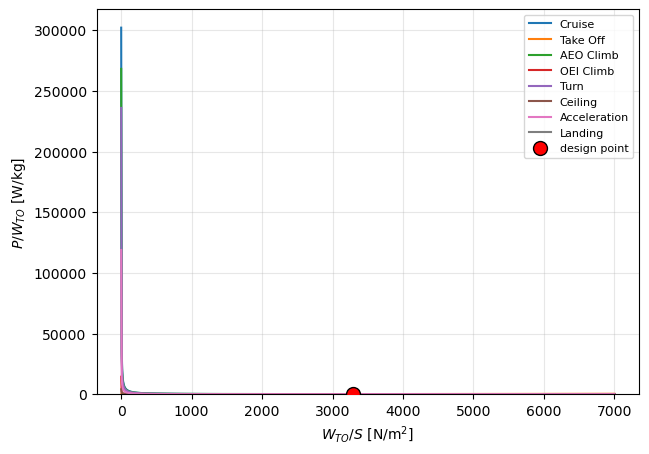

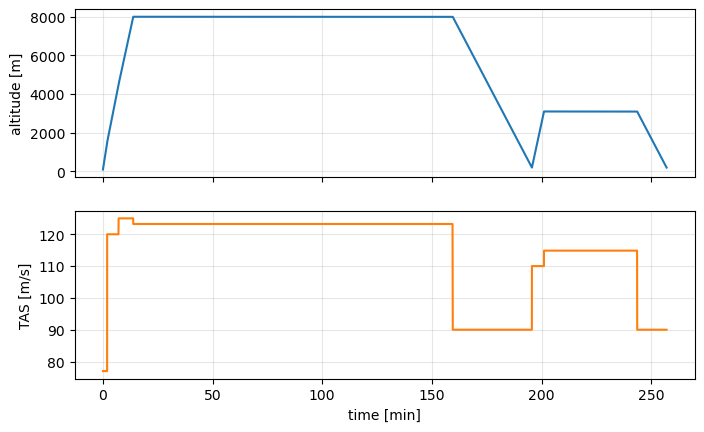

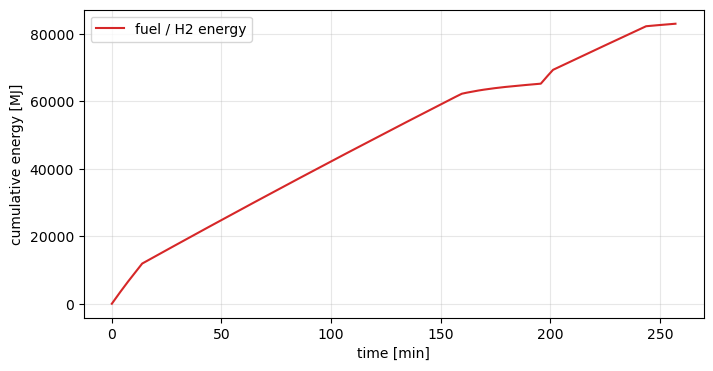

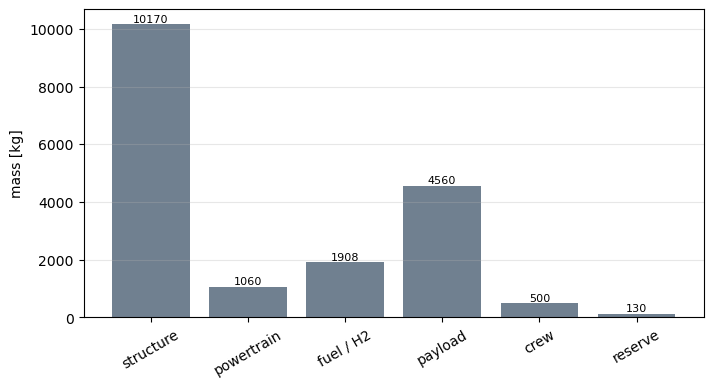

In [4]:
# Every outcome, including the time-resolved ones, via the generic post-processing helpers.
pp.plot_constraint_diagram(aircraft); plt.show()
pp.plot_mission_profile(aircraft);    plt.show()
pp.plot_energy_timeseries(aircraft);  plt.show()
pp.plot_mass_breakdown(aircraft);     plt.show()


## Reference check

The ATR42 reference design (constant gas-turbine efficiency, new code structure).

In [5]:
REFERENCE_WTO = 18327.5  # kg, frozen reference for this configuration
assert abs(r.WTO - REFERENCE_WTO) < 5.0, f'WTO drifted: {r.WTO:.1f} kg'
print(f'OK: WTO = {r.WTO:.1f} kg (reference {REFERENCE_WTO} kg)')

OK: WTO = 18327.5 kg (reference 18327.5 kg)
